In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [25]:
import keras
from keras import layers
import os

# 1. Carichiamo le immagini direttamente dalla cartella in automatico!
# Keras ridimensiona le foto, crea i batch e divide in Train e Validation da solo.

# 1. Puntiamo DIRETTAMENTE alle cartelle che contengono le 6 categorie!
train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

IMG_SIZE = (150, 150) # Dimensione a cui ridimensionare le foto (es. 64x64 pixel)
BATCH_SIZE = 32

# Set di Training (80% dei dati)
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [32]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Classi reali trovate ({num_classes}):", class_names)

Classi reali trovate (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [39]:
# DATA AUGMENTATION
data_augmentation = keras.Sequential(
    [
        # Capovolge l'immagine in orizzontale casualmente (es. un palazzo a destra diventa a sinistra)
        layers.RandomFlip("horizontal"),

        # Ruota casualmente l'immagine fino a un massimo del 10% (circa 36 gradi)
        layers.RandomRotation(0.1),

        # Effettua uno zoom casuale (in avanti o indietro) fino al 10%
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)

In [40]:
model = keras.Sequential([
    # 1. Input Layer Esplicito (sintassi pulita Keras 3)
    layers.Input(shape=(150, 150, 3)),

    # 1.1. LAYER DI AUGMENTATION (Attivo solo durante model.fit)
    data_augmentation,

    # 2. Normalizzazione Pixel (da 0..255 a 0..1)
    layers.Rescaling(1./255),

    # 3. Blocco Conv 1: Dettagli di base (32 filtri)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Blocco Conv 2: Forme e texture (64 filtri)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 5. Blocco Conv 3: Oggetti e paesaggi complessi (128 filtri)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 6. Classificatore Finale
    layers.GlobalAveragePooling2D(), # o Flatten()
    layers.Dense(128, activation='relu'),

    # 6 Neuroni (1 per classe) con Softmax per avere percentuali!
    layers.Dense(num_classes, activation='softmax')
])

In [47]:
# PRE-TRAINED VERSION
# 1. Carichiamo la base di MobileNetV2 di Google
base_model = keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,     # Escludiamo la testa da 1000 classi
    weights='imagenet'     # Usiamo i pesi pre-addestrati da Google
)

# 2. CONGELIAMO la base (non deve aggiornare i suoi pesi)
base_model.trainable = False

/tmp/ipykernel_595/1708093127.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [53]:
# PRE-TRAINED VERSION
# 3. Costruiamo il modello completo con l'API Sequenziale o Funzionale
num_classes = 6

model_pre_trained = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    # Manteniamo il nostro Data Augmentation
    data_augmentation,

    # NOTA: MobileNetV2 si aspetta i pixel tra -1 e 1 anziché tra 0 e 1.
    # Keras ha una funzione apposita per la pre-elaborazione di MobileNetV2!
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),

    # Inseriamo la base pre-addestrata
    base_model,

    # La nostra nuova testa personalizzata
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Opzionale: un pizzico di Dropout per evitare Overfitting
    layers.Dense(num_classes, activation='softmax')
])

In [41]:
# Compilazione
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Mostra un riassunto dell'architettura
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,534 (431.77 KB)

 Trainable params: 110,534 (431.77 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# 4. Compilazione (possiamo usare un learning rate leggermente più basso)
model_pre_trained.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_pre_trained.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 1,367,686 (5.22 MB)

 Non-trainable params: 897,984 (3.43 MB)

In [56]:
model_pre_trained.fit(train_ds, validation_data=val_ds, epochs=8)

Epoch 1/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.7988 - loss: 0.5499 - val_accuracy: 0.8863 - val_loss: 0.3312
Epoch 2/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8586 - loss: 0.3988 - val_accuracy: 0.8843 - val_loss: 0.3233
Epoch 3/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.8672 - loss: 0.3728 - val_accuracy: 0.8930 - val_loss: 0.3052
Epoch 4/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8735 - loss: 0.3527 - val_accuracy: 0.8967 - val_loss: 0.2931
Epoch 5/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.8710 - loss: 0.3584 - val_accuracy: 0.8963 - val_loss: 0.2800
Epoch 6/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8757 - loss: 0.3478 - val_accuracy: 0.8703 - val_loss: 0.3488
Epoch 7/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.8784 - loss: 0.3412 - val_accuracy: 0.8963 - val_loss: 0.2845
Epoch 8/8
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8756 - loss: 0.3410 - val_accu

In [ ]:
# PRE-TRAINED FINE TUNING VERSION
# 1. Sblocca la base
base_model.trainable = True

# 2. Congela tutti i layer TRANNE gli ultimi 20-30
# (MobileNetV2 ha 154 layer in totale)
fine_tune_at = 130

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Ricompila con un Learning Rate piccolo!
model_pre_trained.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Continua il training per altre 5-6 epoche
history_fine = model_pre_trained.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    initial_epoch=8  # Riparte da dove eravamo rimasti!
)

Epoch 9/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.8363 - loss: 0.4479 - val_accuracy: 0.9013 - val_loss: 0.2860
Epoch 10/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.8613 - loss: 0.3714 - val_accuracy: 0.9040 - val_loss: 0.2753
Epoch 11/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.8752 - loss: 0.3442 - val_accuracy: 0.9037 - val_loss: 0.2845
Epoch 12/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 23s 53ms/step - accuracy: 0.8846 - loss: 0.3214 - val_accuracy: 0.9057 - val_loss: 0.2679
Epoch 13/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.8873 - loss: 0.3040 - val_accuracy: 0.9040 - val_loss: 0.2584
Epoch 14/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.8946 - loss: 0.2846 - val_accuracy: 0.9047 - val_loss: 0.2572
Epoch 15/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.8955 - loss: 0.2897 - val_accuracy: 0.9067 - val_loss: 0.2617


In [63]:
# SALVATAGGIO MODELLO
model_pre_trained.save("modello_paesaggi.keras")

In [ ]:
# CARICAMENTO MODELLO (ad es.: per usarlo in una API)
model_paesaggi = keras.models.load_model("modello_paesaggi.keras")

In [ ]:
import numpy as np
import tensorflow as tf
import keras

# 1. Carichiamo un'immagine di test (es. dal folder seg_pred del dataset)
img_path = os.path.join(path, "seg_pred", "seg_pred", "10004.jpg")

# Carichiamo l'immagine con le STESSE dimensioni usate nel training (150x150)
img = keras.utils.load_img(img_path, target_size=(150, 150))

# 2. Caricamento + Array + Batch in 1 riga sola con la scorciatoia [None, ...]
img_tensor = keras.utils.img_to_array(img)[None, ...]

# 3. Predizione pulita e istantanea (zero warning, zero cicli)
predictions = model_pre_trained(img_tensor, training=False)

# 5. Interpretiamo il risultato
# predictions[0] contiene 6 percentuali (una per ogni classe)
predicted_class_index = np.argmax(predictions[0]) # Prende l'indice della probabilità più alta
predicted_class_name = class_names[predicted_class_index]
confidence = np.max(predictions[0]) * 100

print(f"📸 Foto analizzata: {img_path}")
print(f"🎯 Il modello dice che è: **{predicted_class_name.upper()}** con una sicurezza del {confidence:.2f}%!")

📸 Foto analizzata: /kaggle/input/intel-image-classification/seg_pred/seg_pred/10004.jpg
🎯 Il modello dice che è: **BUILDINGS** con una sicurezza del 96.48%!


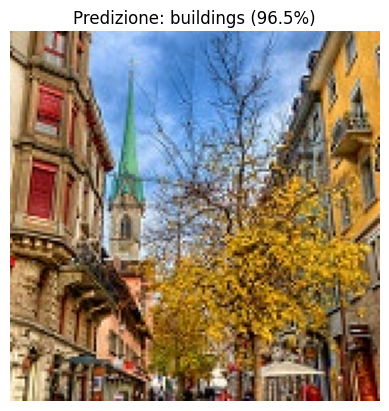

In [61]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title(f"Predizione: {predicted_class_name} ({confidence:.1f}%)")
plt.axis("off")
plt.show()